In [204]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
import torch
from torch.utils.data import DataLoader, Dataset
from sklearn.feature_selection import (
    mutual_info_regression, 
    VarianceThreshold,
    RFECV,
    SequentialFeatureSelector
)
from sklearn.ensemble import ExtraTreesRegressor
from feature_engine.selection import RecursiveFeatureElimination
from boruta import BorutaPy

pd.set_option('display.max_columns', None)

In [205]:
# reading data from source
train = pd.read_csv(r'..\data\train_FD001.txt', sep=r'\s+', header=None)
test = pd.read_csv(r'..\data\test_FD001.txt', sep=r'\s+', header=None)
test_labels = pd.read_csv(r'..\data\RUL_FD001.txt', header=None)

# feature names as written in readme file
columns = (
    ["unit_number", "time_cycles"]
    + [f"operational_setting_{i}" for i in range(1, 4)]
    + [f"sensor_measurement_{i}" for i in range(1, 22)]
)

# renaming features
train.columns = columns
test.columns = columns
test_labels.columns = ['rul']

In [206]:
train.describe()

,unit_number,time_cycles,operational_setting_1,operational_setting_2,operational_setting_3,sensor_measurement_1,sensor_measurement_2,sensor_measurement_3,sensor_measurement_4,sensor_measurement_5,sensor_measurement_6,sensor_measurement_7,sensor_measurement_8,sensor_measurement_9,sensor_measurement_10,sensor_measurement_11,sensor_measurement_12,sensor_measurement_13,sensor_measurement_14,sensor_measurement_15,sensor_measurement_16,sensor_measurement_17,sensor_measurement_18,sensor_measurement_19,sensor_measurement_20,sensor_measurement_21
count,20631.000000,20631.000000,20631.000000,20631.000000,20631.0,20631.00,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.000000,20631.000000,20631.000000,20631.0,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.0,20631.0,20631.000000,20631.000000
mean,51.506568,108.807862,-0.000009,0.000002,100.0,518.67,642.680934,1590.523119,1408.933782,1.462000e+01,21.609803,553.367711,2388.096652,9065.242941,1.3,47.541168,521.413470,2388.096152,8143.752722,8.442146,3.000000e-02,393.210654,2388.0,100.0,38.816271,23.289705
std,29.227633,68.880990,0.002187,0.000293,0.0,0.00,0.500053,6.131150,9.000605,5.329200e-15,0.001389,0.885092,0.070985,22.082880,0.0,0.267087,0.737553,0.071919,19.076176,0.037505,3.469531e-18,1.548763,0.0,0.0,0.180746,0.108251
min,1.000000,1.000000,-0.008700,-0.000600,100.0,518.67,641.210000,1571.040000,1382.250000,1.462000e+01,21.600000,549.850000,2387.900000,9021.730000,1.3,46.850000,518.690000,2387.880000,8099.940000,8.324900,3.000000e-02,388.000000,2388.0,100.0,38.140000,22.894200
25%,26.000000,52.000000,-0.001500,-0.000200,100.0,518.67,642.325000,1586.260000,1402.360000,1.462000e+01,21.610000,552.810000,2388.050000,9053.100000,1.3,47.350000,520.960000,2388.040000,8133.245000,8.414900,3.000000e-02,392.000000,2388.0,100.0,38.700000,23.221800
50%,52.000000,104.000000,0.000000,0.000000,100.0,518.67,642.640000,1590.100000,1408.040000,1.462000e+01,21.610000,553.440000,2388.090000,9060.660000,1.3,47.510000,521.480000,2388.090000,8140.540000,8.438900,3.000000e-02,393.000000,2388.0,100.0,38.830000,23.297900
75%,77.000000,156.000000,0.001500,0.000300,100.0,518.67,643.000000,1594.380000,1414.555000,1.462000e+01,21.610000,554.010000,2388.140000,9069.420000,1.3,47.700000,521.950000,2388.140000,8148.310000,8.465600,3.000000e-02,394.000000,2388.0,100.0,38.950000,23.366800
max,100.000000,362.000000,0.008700,0.000600,100.0,518.67,644.530000,1616.910000,1441.490000,1.462000e+01,21.610000,556.060000,2388.560000,9244.590000,1.3,48.530000,523.380000,2388.560000,8293.720000,8.584800,3.000000e-02,400.000000,2388.0,100.0,39.430000,23.618400


In [207]:
test.describe()

,unit_number,time_cycles,operational_setting_1,operational_setting_2,operational_setting_3,sensor_measurement_1,sensor_measurement_2,sensor_measurement_3,sensor_measurement_4,sensor_measurement_5,sensor_measurement_6,sensor_measurement_7,sensor_measurement_8,sensor_measurement_9,sensor_measurement_10,sensor_measurement_11,sensor_measurement_12,sensor_measurement_13,sensor_measurement_14,sensor_measurement_15,sensor_measurement_16,sensor_measurement_17,sensor_measurement_18,sensor_measurement_19,sensor_measurement_20,sensor_measurement_21
count,13096.000000,13096.000000,13096.000000,13096.000000,13096.0,13096.00,13096.000000,13096.000000,13096.000000,1.309600e+04,13096.000000,13096.000000,13096.000000,13096.000000,1.309600e+04,13096.000000,13096.000000,13096.000000,13096.000000,13096.000000,1.309600e+04,13096.000000,13096.0,13096.0,13096.000000,13096.000000
mean,51.543907,76.836515,-0.000011,0.000004,100.0,518.67,642.475088,1588.099204,1404.735362,1.462000e+01,21.609701,553.757523,2388.070964,9058.407363,1.300000e+00,47.416204,521.747724,2388.071025,8138.947817,8.425844,3.000000e-02,392.571625,2388.0,100.0,38.892502,23.335743
std,28.289423,53.057749,0.002203,0.000294,0.0,0.00,0.400899,5.003274,6.688309,1.776425e-15,0.001704,0.681286,0.057442,11.436261,2.220531e-16,0.195917,0.559627,0.056934,10.188605,0.029009,1.040874e-17,1.233577,0.0,0.0,0.141681,0.084120
min,1.000000,1.000000,-0.008200,-0.000600,100.0,518.67,641.130000,1569.040000,1384.390000,1.462000e+01,21.600000,550.880000,2387.890000,9024.530000,1.300000e+00,46.800000,519.380000,2387.890000,8108.500000,8.332800,3.000000e-02,389.000000,2388.0,100.0,38.310000,22.935400
25%,28.000000,33.000000,-0.001500,-0.000200,100.0,518.67,642.197500,1584.600000,1399.950000,1.462000e+01,21.610000,553.310000,2388.030000,9051.020000,1.300000e+00,47.270000,521.380000,2388.030000,8132.310000,8.405600,3.000000e-02,392.000000,2388.0,100.0,38.800000,23.281600
50%,52.000000,69.000000,-0.000000,-0.000000,100.0,518.67,642.460000,1587.990000,1404.440000,1.462000e+01,21.610000,553.800000,2388.070000,9057.320000,1.300000e+00,47.410000,521.780000,2388.070000,8138.390000,8.424900,3.000000e-02,393.000000,2388.0,100.0,38.900000,23.339200
75%,76.000000,113.000000,0.001500,0.000300,100.0,518.67,642.740000,1591.362500,1409.050000,1.462000e+01,21.610000,554.240000,2388.110000,9064.110000,1.300000e+00,47.540000,522.150000,2388.110000,8144.360000,8.444300,3.000000e-02,393.000000,2388.0,100.0,38.990000,23.393600
max,100.000000,303.000000,0.007800,0.000700,100.0,518.67,644.300000,1607.550000,1433.360000,1.462000e+01,21.610000,555.840000,2388.300000,9155.030000,1.300000e+00,48.260000,523.760000,2388.320000,8220.480000,8.541400,3.000000e-02,397.000000,2388.0,100.0,39.410000,23.641900


### Standard Linear RUL

In [208]:
# maximum cycle for each engine unit
max_cycles = train.groupby('unit_number')['time_cycles'].max().reset_index()
max_cycles.columns = ['unit_number', 'max_cycle']

# Merge this maximum back into the main dataframe
train = train.merge(max_cycles, on='unit_number', how='left')

# Calculate the standard linear RUL
train['linear_rul'] = train['max_cycle'] - train['time_cycles']

# Drop the helper column
train.drop(columns=['max_cycle'], inplace=True)

### Piecewise Linear RUL

In [209]:
# industry standard cap for FD001
R_max = 120

# Apply the ceiling cap: if linear_rul > 125, force it to be 125
train['piecewise_rul'] = train['linear_rul'].clip(upper=R_max)

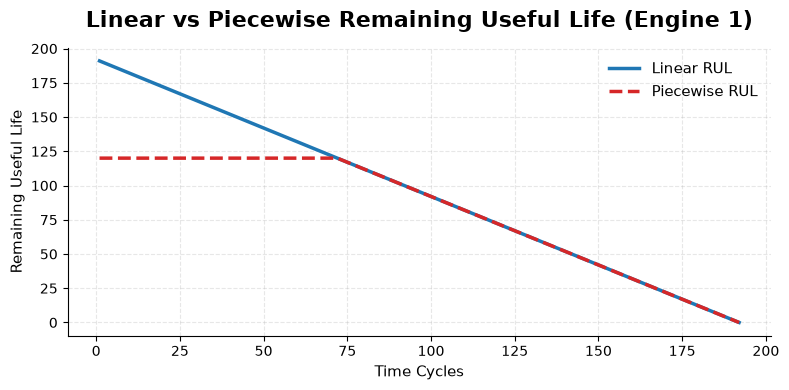

In [210]:
engine = train.loc[train["unit_number"] == 1].sort_values("time_cycles")

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(
    engine["time_cycles"],
    engine["linear_rul"],
    label="Linear RUL",
    color="#1f77b4",
    linewidth=2.5,
)

ax.plot(
    engine["time_cycles"],
    engine["piecewise_rul"],
    label="Piecewise RUL",
    color="#d62728",
    linewidth=2.5,
    linestyle="--",
)

ax.set_title(
    "Linear vs Piecewise Remaining Useful Life (Engine 1)",
    fontsize=16,
    fontweight="bold",
    pad=15,
)

ax.set_xlabel("Time Cycles", fontsize=11)
ax.set_ylabel("Remaining Useful Life", fontsize=11)

ax.grid(
    linestyle="--",
    alpha=0.3,
)

ax.legend(
    frameon=False,
    fontsize=11,
)

sns.despine()

plt.tight_layout()
plt.show()

In [211]:
X = train.drop(['time_cycles', 'linear_rul', 'piecewise_rul'], axis=1)
y_linear = train['linear_rul']
y_piecewise = train['piecewise_rul']

X_test = test.drop(['time_cycles'], axis=1)
y_test = test_labels.copy(deep=True)

### Feature Engineering

Based on variance threshold

In [212]:
selector = VarianceThreshold(threshold=0)
selector.fit(X)

# Features kept
kept_features = X.columns[selector.get_support()]

# Features dropped
dropped_features = X.columns[~selector.get_support()]

print("Dropped Features:")
print(dropped_features.tolist())

Dropped Features:
['operational_setting_3', 'sensor_measurement_1', 'sensor_measurement_5', 'sensor_measurement_10', 'sensor_measurement_16', 'sensor_measurement_18', 'sensor_measurement_19']


Mutual Information

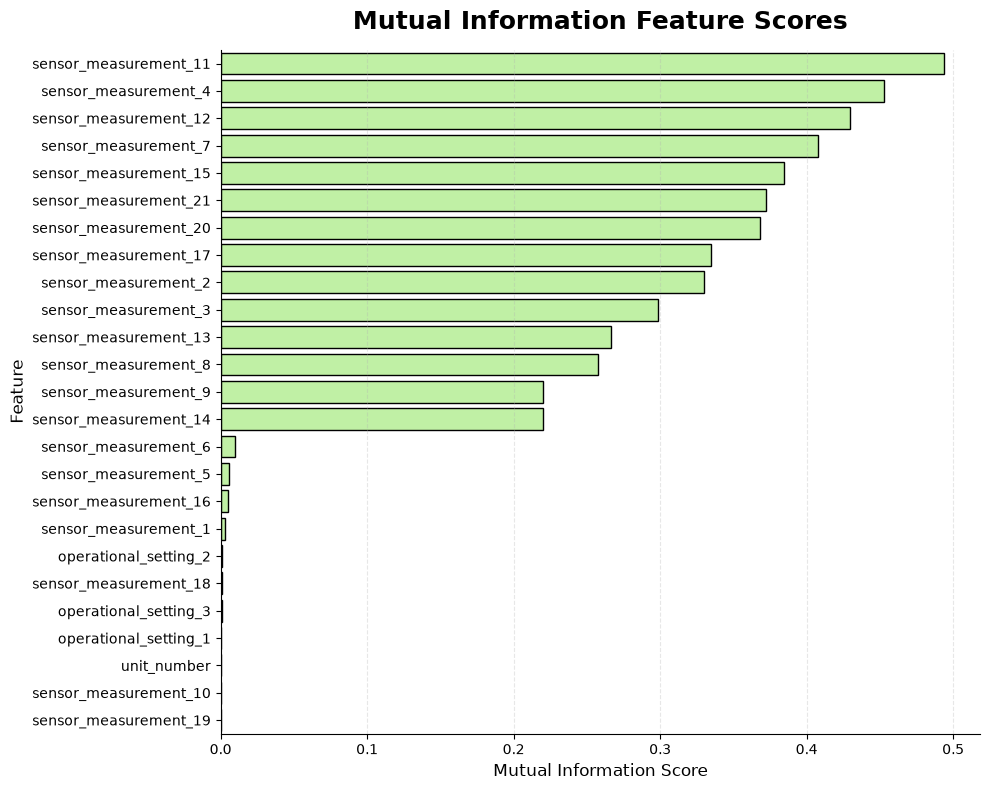

In [213]:
mi_scores = mutual_info_regression(X, y_piecewise, random_state=42)

mi_df = (
    pd.DataFrame(
        {
            "Feature": X.columns,
            "Mutual Information": mi_scores,
        }
    )
    .sort_values(
        "Mutual Information",
        ascending=False,
    )
)

fig, ax = plt.subplots(figsize=(10, 8))

sns.barplot(
    data=mi_df,
    x="Mutual Information",
    y="Feature",
    color="#BDFC98",
    edgecolor="black",
    ax=ax,
)

ax.set_title(
    "Mutual Information Feature Scores",
    fontsize=18,
    fontweight="bold",
    pad=15,
)

ax.set_xlabel(
    "Mutual Information Score",
    fontsize=12,
)

ax.set_ylabel(
    "Feature",
    fontsize=12,
)

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.3,
)

sns.despine()

plt.tight_layout()
plt.show()

RFECV

In [214]:
ETREES_PARAMS = {
    'bootstrap': True,
    'ccp_alpha': 0.0,
    'criterion': 'squared_error',
    'max_depth': None,
    'max_features': 1.0,
    'max_leaf_nodes': None,
    'max_samples': None,
    'min_impurity_decrease': 0.0,
    'min_samples_leaf': 1,
    'min_samples_split': 2,
    'min_weight_fraction_leaf': 0.0,
    'monotonic_cst': None,
    'n_estimators': 400,
    'n_jobs': -1,
    'oob_score': False,
    'random_state': 42,
    'verbose': 0,
    'warm_start': False
}

rfe = RFECV(
    estimator=ExtraTreesRegressor(**ETREES_PARAMS),
    cv=5,
    scoring='neg_mean_squared_error',
    min_features_to_select=1,
    n_jobs=-1,
    importance_getter='auto',
)

rfe.fit(X, y_piecewise)

# Features kept
kept_features = X.columns[rfe.get_support()]

# Features dropped
dropped_features = X.columns[~rfe.get_support()]

print("Dropped Features:")
print(dropped_features.tolist())

Dropped Features:
['operational_setting_3']


Boruta

In [216]:
etree = ExtraTreesRegressor(**ETREES_PARAMS)

feat_selector = BorutaPy(
    etree, 
    n_estimators='auto', 
    verbose=2, 
    random_state=42,
    early_stopping=True,
    alpha=0.05, # 5 percent
    n_iter_no_change=10)

feat_selector.fit(X, y_piecewise)

# Features kept
kept_features = X.columns[feat_selector.support_]

# Features dropped
dropped_features = X.columns[~feat_selector.support_]

print("Dropped Features:")
print(dropped_features.tolist())

print('Rank of features')
print(feat_selector.ranking_)

Iteration: 	1 / 100
Confirmed: 	0
Tentative: 	25
Rejected: 	0
Iteration: 	2 / 100
Confirmed: 	0
Tentative: 	25
Rejected: 	0
Early stopping: 2 out of 10
Iteration: 	3 / 100
Confirmed: 	0
Tentative: 	25
Rejected: 	0
Early stopping: 3 out of 10
Iteration: 	4 / 100
Confirmed: 	0
Tentative: 	25
Rejected: 	0
Early stopping: 4 out of 10
Iteration: 	5 / 100
Confirmed: 	0
Tentative: 	25
Rejected: 	0
Early stopping: 5 out of 10
Iteration: 	6 / 100
Confirmed: 	0
Tentative: 	25
Rejected: 	0
Early stopping: 6 out of 10
Iteration: 	7 / 100
Confirmed: 	0
Tentative: 	25
Rejected: 	0
Early stopping: 7 out of 10
Iteration: 	8 / 100
Confirmed: 	15
Tentative: 	1
Rejected: 	9
Iteration: 	9 / 100
Confirmed: 	15
Tentative: 	1
Rejected: 	9
Early stopping: 2 out of 10
Iteration: 	10 / 100
Confirmed: 	15
Tentative: 	1
Rejected: 	9
Early stopping: 3 out of 10
Iteration: 	11 / 100
Confirmed: 	15
Tentative: 	1
Rejected: 	9
Early stopping: 4 out of 10
Iteration: 	12 / 100
Confirmed: 	15
Tentative: 	1
Rejected: 	9
E

Sequential Feature Selector - Forward

In [ ]:
etree = ExtraTreesRegressor(**ETREES_PARAMS)
selector = SequentialFeatureSelector(
    estimator=etree,
    n_features_to_select=5,
    direction='forward',
    scoring='neg_mean_squared_error',
    cv=5,
    n_jobs=-1
)

selector.fit(X, y_piecewise)

# Features kept
kept_features = X.columns[selector.get_support()]

# Features dropped
dropped_features = X.columns[~selector.get_support()]

print("Dropped Features:")
print(dropped_features.tolist())

Dropped Features:
['unit_number', 'operational_setting_1', 'operational_setting_2', 'operational_setting_3', 'sensor_measurement_1', 'sensor_measurement_2', 'sensor_measurement_3', 'sensor_measurement_5', 'sensor_measurement_6', 'sensor_measurement_8', 'sensor_measurement_10', 'sensor_measurement_13', 'sensor_measurement_14', 'sensor_measurement_15', 'sensor_measurement_16', 'sensor_measurement_17', 'sensor_measurement_18', 'sensor_measurement_19', 'sensor_measurement_20', 'sensor_measurement_21']


In [218]:
print("Kept Features:")
print(kept_features.tolist())

Kept Features:
['sensor_measurement_4', 'sensor_measurement_7', 'sensor_measurement_9', 'sensor_measurement_11', 'sensor_measurement_12']


In [219]:
dominant_features = [
    'sensor_measurement_4',
    'sensor_measurement_9',
    'sensor_measurement_11',
    'sensor_measurement_7'
]

In [220]:
def feature_eng(
    df: pd.DataFrame,
    dominant_features: list[str],
    window: int = 5,
    ema_span: int = 5,
) -> pd.DataFrame:
    """
    Perform feature engineering on dominant sensor features.

    Features created
    ----------------
    - Lag (1)
    - First Difference
    - Rolling Mean
    - Rolling Standard Deviation
    - Exponential Moving Average (EMA)
    - Rolling Minimum
    - Rolling Maximum
    - Percentage Change

    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe.

    dominant_features : list[str]
        Features on which feature engineering will be applied.

    window : int, default=5
        Rolling window size.

    ema_span : int, default=5
        Span for exponential moving average.

    Returns
    -------
    pd.DataFrame
        DataFrame with engineered features.
    """

    df = df.copy()

    grouped = df.groupby("unit_number")

    for col in dominant_features:

        # Lag
        df[f"{col}_lag1"] = grouped[col].shift(1)

        # Difference
        df[f"{col}_diff1"] = grouped[col].diff()

        # Rolling statistics
        df[f"{col}_roll_mean"] = grouped[col].transform(
            lambda x: x.rolling(window, min_periods=1).mean()
        )

        df[f"{col}_roll_std"] = grouped[col].transform(
            lambda x: x.rolling(window, min_periods=1).std()
        )

        df[f"{col}_roll_min"] = grouped[col].transform(
            lambda x: x.rolling(window, min_periods=1).min()
        )

        df[f"{col}_roll_max"] = grouped[col].transform(
            lambda x: x.rolling(window, min_periods=1).max()
        )

        # Exponential Moving Average
        df[f"{col}_ema"] = grouped[col].transform(
            lambda x: x.ewm(
                span=ema_span,
                adjust=False,
            ).mean()
        )

        # Percentage Change
        df[f"{col}_pct_change"] = grouped[col].pct_change()

    return df

In [221]:
X = feature_eng(X, dominant_features)
X_test = feature_eng(X_test, dominant_features)

X_test = (
    X_test
    .groupby("unit_number")
    .tail(1)
    .reset_index(drop=True)
)

In [222]:
drop_features = [

    # constant features
    'operational_setting_3', 
    'sensor_measurement_1', 
    'sensor_measurement_5', 
    'sensor_measurement_10', 
    'sensor_measurement_16', 
    'sensor_measurement_18', 
    'sensor_measurement_19',
    'unit_number',
]

X = X.drop(drop_features, axis=1)
X_test = X_test.drop(drop_features, axis=1)

print(X.shape)
print(X_test.shape)

(20631, 49)
(100, 49)


In [225]:
# saving files
X.to_csv(Path(r'..\notebooks\nb_artifacts\X_fe.csv'), index=False)
X_test.to_csv(Path(r'..\notebooks\nb_artifacts\X_test_fe.csv'), index=False)
y_linear.to_csv(Path(r'..\notebooks\nb_artifacts\y_linear.csv'), index=False)
y_piecewise.to_csv(Path(r'..\notebooks\nb_artifacts\y_piecewise.csv'), index=False)
y_test.to_csv(Path(r'..\notebooks\nb_artifacts\y_test.csv'), index=False)

### Rolling Window for Sequential Models

In [43]:
class TrainDataset(Dataset):
    def __init__(
        self,
        data: pd.DataFrame,
        feature_cols: list[str],
        target_col: str = "linear_rul",
        window_size: int = 30,
        stride: int = 1,
    ) -> None:

        super().__init__()

        self.window_size = window_size
        self.feature_cols = feature_cols
        self.target_col = target_col

        self.samples: list[tuple[np.ndarray, np.float32]] = []

        for _, engine_df in data.groupby("unit_number"):

            engine_df = engine_df.sort_values("time_cycles")

            X = engine_df[self.feature_cols].to_numpy(dtype=np.float32)
            y = engine_df[self.target_col].to_numpy(dtype=np.float32)

            n = len(engine_df)

            for start in range(0, n - self.window_size + 1, stride):

                end = start + self.window_size

                window = X[start:end]
                target = y[end - 1]

                self.samples.append((window, target))

    def __len__(self) -> int:
        return len(self.samples)

    def __getitem__(self, idx):

        window, target = self.samples[idx]

        return (
            torch.from_numpy(window),
            torch.tensor(target, dtype=torch.float32),
        )

train_dataset = TrainDataset(
    data=train,
    feature_cols=relevant_cols,
    target_col="piecewise_rul",
    window_size=30,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

In [44]:
class TestDataset(Dataset):
    def __init__(
        self,
        data: pd.DataFrame,
        feature_cols: list[str],
        window_size: int = 30,
    ) -> None:

        super().__init__()

        self.window_size = window_size
        self.feature_cols = feature_cols

        self.samples: list[np.ndarray] = []

        for _, engine_df in data.groupby("unit_number"):

            engine_df = engine_df.sort_values("time_cycles")

            X = engine_df[self.feature_cols].to_numpy(dtype=np.float32)

            window = X[-self.window_size:]

            self.samples.append(window)

    def __len__(self) -> int:
        return len(self.samples)

    def __getitem__(self, idx):

        window = self.samples[idx]

        return torch.from_numpy(window)


# Dataset
test_dataset = TestDataset(
    data=test,
    feature_cols=relevant_cols,
    window_size=30,
)

# DataLoader
test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    pin_memory=torch.cuda.is_available(),
)

In [45]:
for X, y in train_loader:
    print(X)
    print(y)

    print(X.shape)
    print(y.shape)

    break

tensor([[[-1.1000, -1.0000,  0.0593,  ...,  0.5000,  0.3200,  0.4552],
         [ 0.5000,  0.0000, -1.3037,  ...,  0.0000,  0.2400,  1.0710],
         [-0.3000,  0.0000, -0.5778,  ..., -0.5000,  0.0400,  0.3048],
         ...,
         [ 0.2000, -0.8000, -0.7852,  ...,  0.5000,  0.4000,  0.6221],
         [ 0.2000,  0.4000, -1.1111,  ..., -0.5000,  0.6800,  0.2586],
         [ 1.6333, -0.6000, -0.3556,  ...,  0.0000,  0.4800,  0.8386]],

        [[-0.4000, -0.2000, -0.7704,  ...,  0.0000, -0.3600, -0.4262],
         [ 0.8667,  0.4000, -0.6519,  ...,  0.5000, -0.4400,  0.6634],
         [ 0.5000, -0.2000, -0.0889,  ...,  0.0000,  0.3200,  0.0834],
         ...,
         [-0.2000, -0.0000,  0.9778,  ...,  0.5000, -0.5200, -0.9117],
         [ 0.1000,  0.2000,  0.8296,  ...,  1.0000, -0.3600, -0.4276],
         [ 0.2000,  0.8000,  0.5037,  ...,  0.5000, -1.1200, -1.1628]],

        [[ 0.4333,  1.0000, -0.9037,  ...,  0.0000,  1.1600,  0.4034],
         [-2.4667,  0.2000, -0.5037,  ...,  0

In [46]:
for X in test_loader:
    print(X)

    print(X.shape)

    break

tensor([[[-0.9000, -0.6000, -1.3825,  ...,  0.0000,  0.6316,  0.4679],
         [ 0.1000,  0.2000,  0.0000,  ...,  0.0000,  0.9474,  0.6911],
         [ 1.4000,  0.0000, -0.0369,  ..., -2.0000,  0.5263,  0.3080],
         ...,
         [ 0.4667,  0.2000, -0.9401,  ..., -1.0000,  0.6316,  0.2045],
         [-0.8333,  0.8000,  0.6083,  ..., -2.0000,  1.0000,  0.6045],
         [-0.2000,  0.8000,  0.2212,  ...,  0.0000, -0.4737,  0.1429]],

        [[ 1.3000,  0.8000,  0.4793,  ...,  0.0000, -0.6842, -0.8009],
         [-1.2667, -0.6000, -0.2581,  ...,  1.0000, -0.0526,  0.3964],
         [ 0.1667,  0.6000, -0.0369,  ...,  0.0000, -0.1053, -0.8188],
         ...,
         [-0.9667, -0.8000,  0.7189,  ..., -1.0000, -0.1053, -0.3812],
         [ 0.3667, -0.2000,  0.3318,  ..., -1.0000,  0.4737, -0.4232],
         [ 0.6000, -0.2000,  0.1659,  ..., -2.0000, -0.4737, -0.6911]],

        [[-2.4333, -0.6000,  0.7373,  ..., -1.0000, -0.4211, -0.8348],
         [-0.5000,  0.4000,  0.0000,  ...,  1